# Packages

In [109]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.optimize import curve_fit

import joblib

from sklearn.linear_model import SGDClassifier

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance

import warnings


from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

from sklearn.model_selection import learning_curve

import tensorflow as tf
from tensorflow.keras import layers, models

# Analysis and organization

In [110]:
# Carregar o arquivo
df = pd.read_csv('/home/jefferson/Documentos/MEUS TRABALHOS/artigo 4/scripts/data/dados_quantum_walk_T_100_50.csv')

# Visualizar as primeiras linhas
df.head()

,delta_theta,IPR,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,...,prob_193,prob_194,prob_195,prob_196,prob_197,prob_198,prob_199,prob_200,prob_201,prob_202
0,0.000000,16.049482,0.0,2.138135e-13,0.0,2.283053e-10,0.0,5.043424e-08,0.0,0.000004,...,0.000140,0.0,0.000004,0.0,5.043424e-08,0.0,2.283053e-10,0.0,2.138135e-13,0.0
1,0.010686,16.109290,0.0,2.296157e-13,0.0,2.436389e-10,0.0,5.345898e-08,0.0,0.000004,...,0.000146,0.0,0.000004,0.0,5.345898e-08,0.0,2.436389e-10,0.0,2.296157e-13,0.0
2,0.021371,17.274234,0.0,1.693602e-13,0.0,1.838433e-10,0.0,4.131376e-08,0.0,0.000003,...,0.000119,0.0,0.000003,0.0,4.131376e-08,0.0,1.838433e-10,0.0,1.693602e-13,0.0
3,0.032057,17.394967,0.0,3.021244e-13,0.0,3.120592e-10,0.0,6.652273e-08,0.0,0.000005,...,0.000170,0.0,0.000005,0.0,6.652273e-08,0.0,3.120592e-10,0.0,3.021244e-13,0.0
4,0.042743,21.982325,0.0,2.373574e-13,0.0,2.485749e-10,0.0,5.372293e-08,0.0,0.000004,...,0.000141,0.0,0.000004,0.0,5.372293e-08,0.0,2.485749e-10,0.0,2.373574e-13,0.0


In [111]:
# Seleciona as colunas e mantém como um DataFrame, mas colocando values ele cria uma nova matriz
df_probs = df.filter(like='prob_')
df_probs.head()

,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,prob_8,prob_9,...,prob_193,prob_194,prob_195,prob_196,prob_197,prob_198,prob_199,prob_200,prob_201,prob_202
0,0.0,2.138135e-13,0.0,2.283053e-10,0.0,5.043424e-08,0.0,0.000004,0.0,0.000140,...,0.000140,0.0,0.000004,0.0,5.043424e-08,0.0,2.283053e-10,0.0,2.138135e-13,0.0
1,0.0,2.296157e-13,0.0,2.436389e-10,0.0,5.345898e-08,0.0,0.000004,0.0,0.000146,...,0.000146,0.0,0.000004,0.0,5.345898e-08,0.0,2.436389e-10,0.0,2.296157e-13,0.0
2,0.0,1.693602e-13,0.0,1.838433e-10,0.0,4.131376e-08,0.0,0.000003,0.0,0.000119,...,0.000119,0.0,0.000003,0.0,4.131376e-08,0.0,1.838433e-10,0.0,1.693602e-13,0.0
3,0.0,3.021244e-13,0.0,3.120592e-10,0.0,6.652273e-08,0.0,0.000005,0.0,0.000170,...,0.000170,0.0,0.000005,0.0,6.652273e-08,0.0,3.120592e-10,0.0,3.021244e-13,0.0
4,0.0,2.373574e-13,0.0,2.485749e-10,0.0,5.372293e-08,0.0,0.000004,0.0,0.000141,...,0.000141,0.0,0.000004,0.0,5.372293e-08,0.0,2.485749e-10,0.0,2.373574e-13,0.0


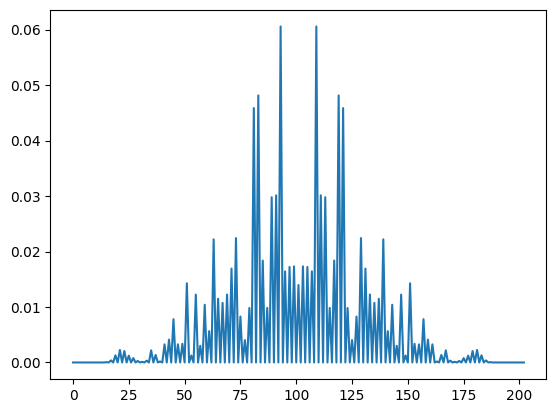

In [112]:
plt.plot(df_probs.iloc[25].values)
plt.show()

List of IPR

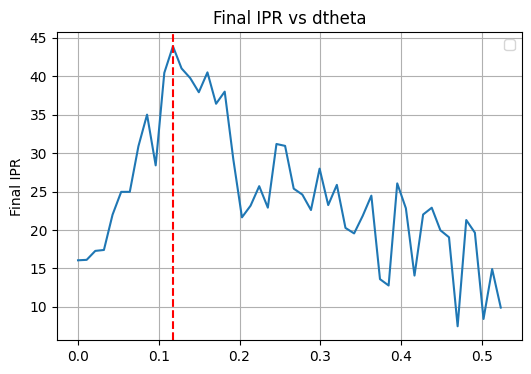

In [113]:
IPR_list = df['IPR']

plt.figure(figsize=(6,4))
plt.plot(df['delta_theta'].values[:2500],df['IPR'].values[:2500])
plt.axvline(x=df['delta_theta'].iloc[np.argmax(IPR_list)], color='red', linestyle='--')
plt.title('Final IPR vs dtheta')
plt.ylabel('Final IPR')
plt.legend()
plt.grid(True)
plt.show()

In [114]:
df.iloc[np.argmax(IPR_list)]
critical_exp = df['delta_theta'].iloc[np.argmax(IPR_list)]
critical_exp

np.float64(0.1175425822771691)

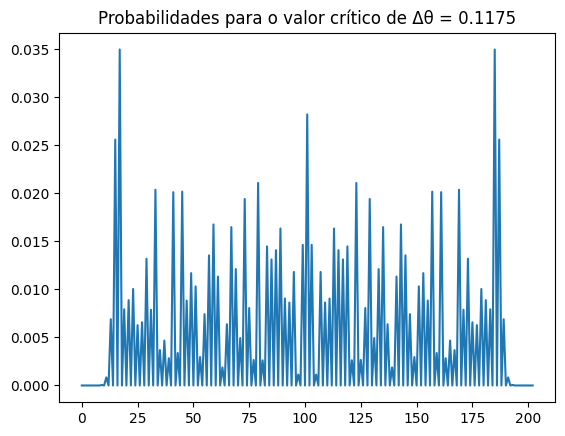

In [115]:
plt.plot(df_probs.iloc[np.argmax(IPR_list)].values)
plt.title(f'Probabilidades para o valor crítico de Δθ = {critical_exp:.4f}')
plt.show()

Data separation for training: Label 0 is assigned to delocalized states (ranging from $0$ to $50$), and Label 1 to localized states (ranging from $200$ to $250$).

In [116]:
# Assigning labels to the training data

n_total = len(df)
ponto_de_corte = np.argmax(df['IPR'].values)  # Onde os 0s terminam e os 1s começam

# Cria a coluna: metade 0, metade 1
coluna_rotulo = np.concatenate([
    np.zeros(ponto_de_corte), 
    np.ones(n_total - ponto_de_corte)
])

# Adiciona a coluna ao DataFrame e garanto que seja inteira
df_probs['label'] = coluna_rotulo.astype(int)

Pego os 50 primeiros deslocalizados e depois mais 50 localizados

In [117]:
df_training = df_probs.iloc[np.r_[0:8, 42:50]]

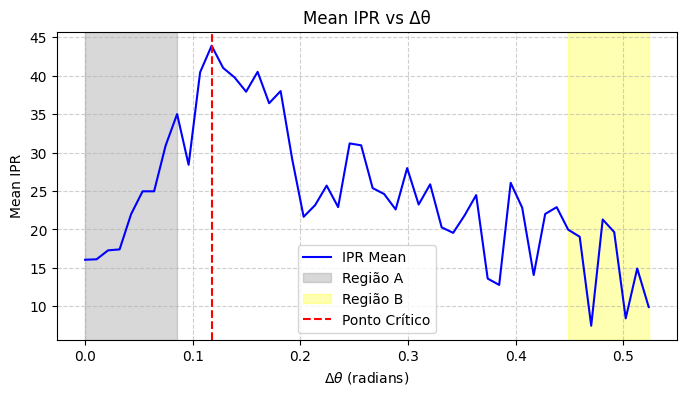

In [118]:
plt.figure(figsize=(8, 4))
plt.plot(df['delta_theta'].values,df['IPR'].values, label='IPR Mean', color='blue', zorder=2)

# Colorindo o primeiro intervalo [0:300]
plt.axvspan(df['delta_theta'].values[:][0], df['delta_theta'].values[:][8], 
            color='gray', alpha=0.3, label='Região A')

# Colorindo o segundo intervalo [700:1000]
# Nota: se o índice for 1000, use 999 para não estourar o limite do array
plt.axvspan(df['delta_theta'].values[:][42], df['delta_theta'].values[:][49], 
            color='yellow', alpha=0.3, label='Região B')

plt.title('Mean IPR vs Δθ')
plt.xlabel(r'$\Delta\theta$ (radians)')
plt.ylabel('Mean IPR')
plt.axvline(x=critical_exp, color='red', linestyle='--', label='Ponto Crítico')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

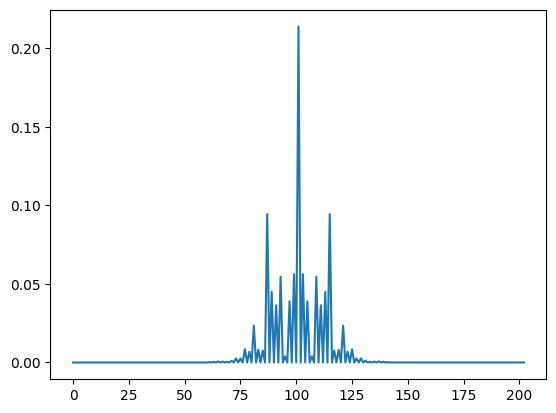

In [119]:
plt.plot(df_probs.iloc[49].values[:-1])
plt.show()

In [120]:
len(df_probs.iloc[49].values)

204

Spliting 80% for training data and 20% for testing model's accuracy. Choice made radomly.

In [121]:
# 1. Definimos o Seed para reprodutibilidade
seed = 42

# 2. Criamos o set de Treino (80%)
df_train = df_training.sample(frac=0.8, random_state=seed)

# 3. Criamos o set de Teste (o que sobrou)
# O .drop() remove as linhas que já foram para o treino
df_test = df_training.drop(df_train.index)

# NN Conv

In [122]:
def sigmoide_automatica(x, y):
    # --- AUTO-CHUTE (O segredo para não falhar) ---
    # Centro (x0): Onde o y está mais próximo de 0.5
    x0_chute = x[np.argmin(np.abs(y - 0.5))]
    
    # Inclinação (k): Estimada pela diferença entre os extremos
    # Se a curva sobe, k é positivo. Se desce, k é negativo.
    k_chute = (y[-1] - y[0]) / (x[-1] - x[0]) * 4 

    # Função modelo: Sigmóide padrão
    def f(x, k, x0):
        return 1 / (1 + np.exp(-k * (x - x0)))

    # Ajuste com os chutes calculados automaticamente
    popt, pcov = curve_fit(f, x, y, p0=[k_chute, x0_chute])
    
    return popt # Retorna [k, x0]

In [123]:
df_train = df_train.drop(columns=[df_train.columns[0], df_train.columns[-2]])

In [124]:
# Supondo que 'dados' seja sua tabela (DataFrame ou Array)
# 1. Separar as características (X) do label (y)
# Se a última coluna é o label:
X = df_train.iloc[:, :-1]  # Pega todas as colunas menos a última
y = df_train.iloc[:, -1]   # Pega apenas a última coluna

# 2. Verificar o número de sítios
n_amostras = X.shape[0]
n_sitios = X.shape[1]

# 3. O RESHAPE MÁGICO
# Transformamos de (amostras, sitios) para (amostras, sitios, 1)
X_reshaped = X.values.reshape(n_amostras, n_sitios, 1)

In [125]:
df_probs = df_probs.drop(columns=[df_probs.columns[0], df_probs.columns[-2], df_probs.columns[-1]])
df_probs_test_reshaped = df_probs.values.reshape(df_probs.shape[0], df_probs.shape[1], 1)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4000 - loss: 0.6933 - val_accuracy: 0.3333 - val_loss: 0.6936
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6000 - loss: 0.6919 - val_accuracy: 0.3333 - val_loss: 0.6956
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.6000 - loss: 0.6911 - val_accuracy: 0.3333 - val_loss: 0.6983
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6000 - loss: 0.6871 - val_accuracy: 0.3333 - val_loss: 0.7033
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6000 - loss: 0.6854 - val_accuracy: 0.3333 - val_loss: 0.7110
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.6000 - loss: 0.6785 - val_accuracy: 0.3333 - val_loss: 0.7231
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.6000 - loss: 0.6713 - val_accuracy: 0.3333 - val_loss: 0.7409
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6000 - loss: 0.6682 - val_accuracy: 0.3333 - val_loss: 0.7637

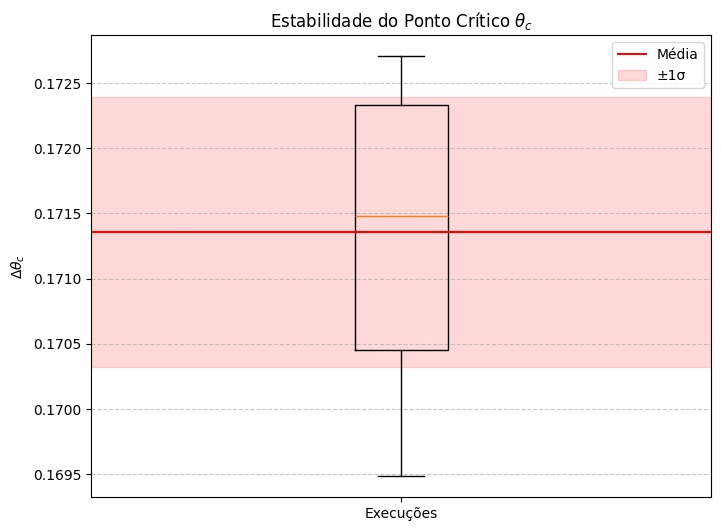

In [126]:
warnings.filterwarnings("ignore")

# Configuração
n_execucoes = 100
pontos_criticos_p = []

n_filtros = X.shape[1]  # Número de sítios como número de filtros na primeira camada
    
model = models.Sequential([
    # --- PRIMEIRA CAMADA CONVOLUCIONAL ---
    # input_shape=(lattice_size, 1) -> O '1' indica que temos 1 canal (intensidade)
    layers.Conv1D(filters=n_filtros, kernel_size=3, padding='same', 
                    activation='relu', input_shape=(X.shape[1], 1)),
    layers.Dropout(0.5), # Dropout para evitar overfitting
    
    # --- SEGUNDA CAMADA (Metade dos filtros) ---
    layers.Conv1D(filters=int(np.ceil(n_filtros/2)), kernel_size=3, 
                    padding='same', activation='relu'),
    layers.Dropout(0.5),
    
    # --- TERCEIRA CAMADA (Um quarto dos filtros) ---
    layers.Conv1D(filters=int(np.ceil(n_filtros/4)), kernel_size=3, 
                    padding='same', activation='relu'),
    
    # --- QUARTA CAMADA (Um oitavo dos filtros) ---
    layers.Conv1D(filters=int(np.ceil(n_filtros/8)), kernel_size=3, 
                    padding='same', activation='relu'),
    layers.Dropout(0.2),
    
    # --- CAMADA FINAL (Densa) ---
    layers.Flatten(), # Achata a saída da convolução para entrar na camada densa
    layers.Dense(2, activation='softmax') # 2 neurônios para probabilidades binárias
])
# Compilação conforme o artigo
model.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

for i in range(n_execucoes):

    model.fit(
        X_reshaped, y,
    epochs=50,               # Comece com 50, ajuste se necessário
    batch_size=32,           # Valor padrão comum
    validation_split=0.2,    # Usa 20% dos dados para validar durante o treino
    verbose=1                # Mostra o progresso na tela
    )

    probs = model.predict(df_probs_test_reshaped)
    delta_theta_trans = df.filter(like='delta_theta').iloc[:2500].values.flatten()
    prob_delocalized = probs[:, 0]

    try:
        res_fit = sigmoide_automatica(delta_theta_trans, prob_delocalized)
        x0 = res_fit[1]
    except Exception:
        x0 = 0

    pontos_criticos_p.append(x0)
    print(i)

# Estatísticas
media = np.mean(pontos_criticos_p)
desvio = np.std(pontos_criticos_p)

# Plot
plt.figure(figsize=(8, 6))

# Boxplot (um único)
plt.boxplot(pontos_criticos_p, patch_artist=False)

# Média (linha horizontal)
plt.axhline(media, color='red', linestyle='-', linewidth=1.5, label='Média')

# Banda de desvio padrão
plt.axhspan(media - desvio, media + desvio, 
            color='red', alpha=0.15, label='±1σ')

# Estética
plt.title("Estabilidade do Ponto Crítico " + r"$\theta_c$")
plt.ylabel(r"$\Delta\theta_c$")
plt.xticks([1], ['Execuções'])

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.show()

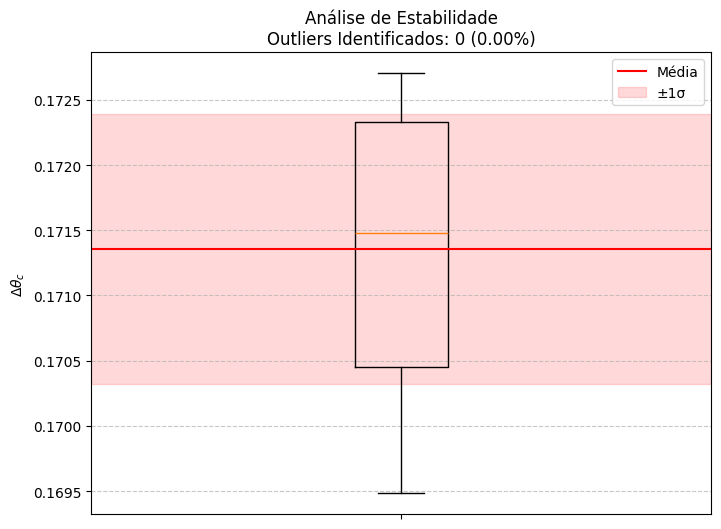

In [128]:
plt.figure(figsize=(8, 6))

# --- 2. O Segredo: Guardar o retorno do boxplot ---
# Ao atribuir o plot a uma variável (bp), temos acesso a todos os dados internos
bp = plt.boxplot(pontos_criticos_p, patch_artist=False)

# --- 3. Extraindo os Outliers nativamente ---
# 'fliers' refere-se aos pontos que ficam fora dos bigodes
# Pegamos o primeiro elemento [0] pois temos apenas um boxplot
outliers_extraidos = bp['fliers'][0].get_ydata()

# --- 4. Cálculos de Porcentagem ---
n_outliers = len(outliers_extraidos)
total_pontos = len(pontos_criticos_p)
porcentagem = (n_outliers / total_pontos) * 100

# --- 5. Estética e Exibição ---
media = np.mean(pontos_criticos_p)
desvio = np.std(pontos_criticos_p)
plt.axhline(media, color='red', linestyle='-', label='Média')
# Banda de desvio padrão
plt.axhspan(media - desvio, media + desvio, 
            color='red', alpha=0.15, label='±1σ')
plt.title(f"Análise de Estabilidade\nOutliers Identificados: {n_outliers} ({porcentagem:.2f}%)")
plt.ylabel(r"$\Delta\theta_c$")
plt.legend()
plt.xticks([1], [])

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()